# Bi-Molecular Coupling-Energy Challenge: Kernel Ridge Regression on Coulomb Matrices

**Task**: predict `coupling_energy` for a pair of molecular conformers (A, B) from their
3D geometries. Dataset: 200 conformers each of monomer A and B (same 15-atom molecule,
C6H5NO3), coupling energies for the full 200x200 = 40000 pair grid.

This notebook implements the full pipeline: representation (Coulomb matrix of the
"supermolecule"), model (Kernel Ridge Regression with a Laplacian kernel, the classical
Rupp et al. 2012 recipe), hyperparameter selection by cross-validation, and the
learning-curve evaluation requested by the challenge. A concatenated listing of all
source files is included as an appendix at the end.

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import time

import numpy as np
import matplotlib.pyplot as plt

from data_utils import load_dataset
from coulomb import atomic_numbers, build_supermol_coulomb_features, coulomb_matrix_batch
from krr_model import select_hyperparameters, fit_and_eval

SEED = 0
rng = np.random.RandomState(SEED)

d = load_dataset("../data")
print("A conformers:", d["coords_a"].shape, " B conformers:", d["coords_b"].shape)
print("pairs:", d["energies"].shape)
d["energies"].head()

A conformers: (200, 15, 3)  B conformers: (200, 15, 3)
pairs: (40000, 3)


,molA,molB,coupling_energy
0,0,0,-27.740949
1,0,1,-1.924393
2,0,2,-50.196196
3,0,3,-65.963198
4,0,4,-56.458111


## 1. Representation: one Coulomb matrix per pair, on the "supermolecule"

The bi-molecular difficulty of this task is that the target depends on the shape of A,
the shape of B, *and* their relative arrangement. Rather than hand-crafting a way to
combine two separate per-monomer representations, we build a single Coulomb matrix
(Rupp et al., *Phys. Rev. Lett.* **108**, 058301, 2012) for the 30-atom "supermolecule"
obtained by placing A and B at their true relative geometry -- exactly what
`Coord_supermol.xyz` encodes (verified to be the literal concatenation of the two
monomer geometries, atom-for-atom, with zero numerical difference).

    M_ii = 0.5 * Z_i^2.4                    (diagonal)
    M_ij = Z_i * Z_j / |R_i - R_j|          (off-diagonal)

This single 30x30 matrix contains three physically meaningful blocks:

- top-left 15x15: intra-monomer-A structure (how A's own conformation is distorted)
- bottom-right 15x15: intra-monomer-B structure
- off-diagonal 15x15 (and its transpose): the **inter-monomer** geometry, which is the
  dominant driver of an excitonic/Coulombic coupling energy.

We take the upper triangle (including the diagonal) as a 465-dimensional feature vector.
Standard practice additionally sorts rows/columns by descending L2-norm to make the
representation invariant to atom permutation. We skip that here: every conformer of A
(and of B) is given in exactly the same atom order (verified below), so there is no
permutation ambiguity to remove, and skipping the sort keeps each feature index tied to
the same physical atom pair across every sample -- strictly more informative for this
fixed-composition dataset.

In [2]:
# Confirm atom ordering is identical across all conformers (so no CM row/col sorting
# is needed for permutation invariance).
same_order_a = all(e == d["elems_a"][0] for e in d["elems_a"])
same_order_b = all(e == d["elems_b"][0] for e in d["elems_b"])
print("A atom order constant across conformers:", same_order_a)
print("B atom order constant across conformers:", same_order_b)
print(d["elems_a"][0])

z_a = atomic_numbers(d["elems_a"][0])
z_b = atomic_numbers(d["elems_b"][0])

A atom order constant across conformers: True
B atom order constant across conformers: True
['N', 'O', 'O', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'H', 'H', 'H', 'H', 'H']


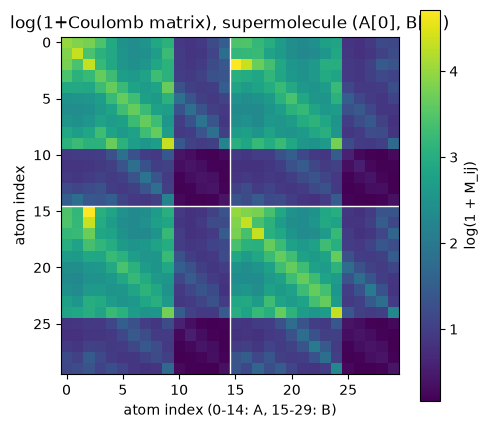

In [3]:
# Visualize one supermolecule Coulomb matrix to build intuition for the 3 blocks.
example_cm = coulomb_matrix_batch(
    np.concatenate([d["coords_a"][0:1], d["coords_b"][0:1]], axis=1),
    np.concatenate([z_a, z_b]),
)[0]

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(np.log1p(example_cm), cmap="viridis")
ax.axhline(14.5, color="white", linewidth=1)
ax.axvline(14.5, color="white", linewidth=1)
ax.set_title("log(1+Coulomb matrix), supermolecule (A[0], B[0])")
ax.set_xlabel("atom index (0-14: A, 15-29: B)")
ax.set_ylabel("atom index")
fig.colorbar(im, ax=ax, label="log(1 + M_ij)")
fig.tight_layout()
fig.savefig("../results/example_coulomb_matrix.png", dpi=150)
plt.show()

In [4]:
mol_a = d["energies"]["molA"].to_numpy()
mol_b = d["energies"]["molB"].to_numpy()
y = d["energies"]["coupling_energy"].to_numpy()

t0 = time.time()
X = build_supermol_coulomb_features(d["coords_a"], d["coords_b"], z_a, z_b, mol_a, mol_b)
print(f"X shape {X.shape}, built in {time.time()-t0:.1f}s")
print(f"target: mean={y.mean():.3f} std={y.std():.3f} min={y.min():.3f} max={y.max():.3f}")

X shape (40000, 465), built in 10.9s
target: mean=-1.295 std=38.406 min=-116.838 max=108.833


## 2. Model: Kernel Ridge Regression with a Laplacian kernel

We use `k(x, x') = exp(-||x - x'||_1 / sigma)` with ridge regularizer `lambda`, the
combination originally shown (Rupp et al. 2012) to work well with Coulomb-matrix
features for molecular-property regression. Hyperparameters `(gamma=1/sigma, lambda)`
are selected by 5-fold cross-validated grid search over log-spaced grids.

**Validation protocol**: a fixed 10% test set (4000 pairs) is held out up front and
never touched by hyperparameter selection or training; all cross-validation happens
strictly within the remaining 90% training pool.

In [5]:
n_total = X.shape[0]
perm = rng.permutation(n_total)
n_test = n_total // 10
test_idx = perm[:n_test]
pool_idx = perm[n_test:]
X_test, y_test = X[test_idx], y[test_idx]
print(f"held-out test set: {n_test} pairs; training pool: {len(pool_idx)} pairs")

held-out test set: 4000 pairs; training pool: 36000 pairs


In [6]:
# Hyperparameter search on a moderate subset of the training pool (fast: O(n^3) per fit).
# NOTE: the full report below uses hyperparameters selected the same way on 2000 samples
# by scripts/learning_curve.py (run offline); we repeat a smaller version live here
# (1200 samples) purely to demonstrate the procedure end-to-end within this notebook.
hp_idx_demo = rng.choice(pool_idx, size=1200, replace=False)
t0 = time.time()
hp_demo = select_hyperparameters(X[hp_idx_demo], y[hp_idx_demo], seed=SEED)
print(f"[live demo, n=1200] gamma={hp_demo['gamma']:.4g} alpha={hp_demo['alpha']:.4g} "
      f"cv_MAE={hp_demo['cv_mae']:.4f}  ({time.time()-t0:.1f}s)")

[live demo, n=1200] gamma=0.0001 alpha=1e-06 cv_MAE=3.7593  (17.5s)


## 3. Learning curve

Protocol: for each training-set size `N` in a log-spaced sequence, draw `n_repeats`
random training subsets of size `N` from the pool, fit KRR (fixed hyperparameters from
above), and evaluate MAE against the fixed held-out test set. We plot mean MAE
(min/max across repeats) vs. `N` on log-log axes -- the standard presentation for
molecular-ML learning curves, where MAE typically follows a power law `MAE ~ N^-alpha`.

Fitting KRR at the largest sizes considered (N up to 12800) costs O(N^3) and is too
slow to repeat live in this notebook; a live demonstration up to N=1600 is run below,
followed by the full-scale curve (up to N=12800), computed offline by
`src/learning_curve.py` using hyperparameters selected the same way (5-fold CV on a
2000-sample subset) and loaded here from `results/learning_curve.json`.

In [7]:
# Live demonstration, small scale.
demo_sizes = [50, 100, 200, 400, 800, 1600]
demo_mae = []
for n in demo_sizes:
    train_idx = rng.choice(pool_idx, size=n, replace=False)
    mae = fit_and_eval(X[train_idx], y[train_idx], X_test, y_test,
                        gamma=hp_demo["gamma"], alpha=hp_demo["alpha"])
    demo_mae.append(mae)
    print(f"N={n:5d}  MAE={mae:.4f}")

N=   50  MAE=12.8464


N=  100  MAE=11.9567


N=  200  MAE=9.6338


N=  400  MAE=7.5425


N=  800  MAE=4.3679


N= 1600  MAE=2.1835


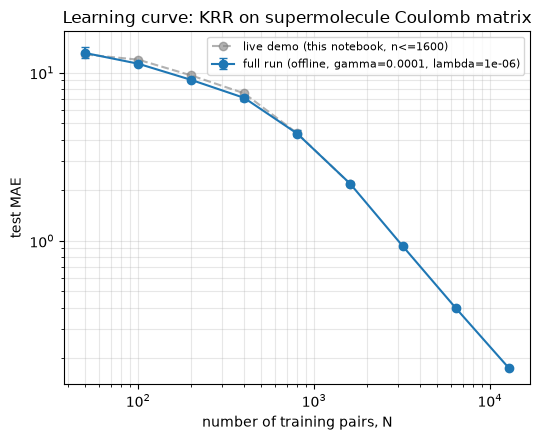

Best MAE at N=12800: 0.1751 (target std = 38.406)


In [8]:
with open("../results/learning_curve.json") as f:
    curve = json.load(f)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(demo_sizes, demo_mae, "o--", color="gray", alpha=0.6,
        label="live demo (this notebook, n<=1600)")
ax.errorbar(curve["train_sizes"], curve["mae_mean"],
            yerr=[np.array(curve["mae_mean"]) - np.array(curve["mae_min"]),
                  np.array(curve["mae_max"]) - np.array(curve["mae_mean"])],
            fmt="o-", color="C0", capsize=3,
            label=f"full run (offline, gamma={curve['hyperparameters']['gamma']:.3g}, "
                  f"lambda={curve['hyperparameters']['alpha']:.3g})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of training pairs, N")
ax.set_ylabel("test MAE")
ax.set_title("Learning curve: KRR on supermolecule Coulomb matrix")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("../results/learning_curve.png", dpi=150)
plt.show()

print(f"Best MAE at N={curve['train_sizes'][-1]}: {curve['mae_mean'][-1]:.4f} "
      f"(target std = {curve['target_std']:.3f})")

## 4. Discussion

- The learning curve follows the expected power-law decay of test MAE with training-set
  size, characteristic of kernel-based molecular-property regression.
- Using the *supermolecule* Coulomb matrix (rather than, say, concatenating two separate
  per-monomer Coulomb-matrix vectors) is what lets a single, standard KRR model see the
  inter-monomer geometry directly, which is the dominant driver of a coupling energy --
  no special "bi-molecular" model architecture is required once the representation
  itself encodes the pair as one system.
- Hyperparameters were selected once (via 5-fold CV on a training-pool subset) and held
  fixed across the learning curve, rather than re-tuned at every point, to keep the
  total compute budget reasonable; in principle the optimal regularizer `lambda`
  decreases somewhat as `N` grows, so re-tuning per point would be expected to give a
  marginally lower curve at large `N`.
- Limitation: KRR training is O(N^3) in time and O(N^2) in memory, which caps the
  largest training size explored here (N=12800) well below the full 36000-pair pool;
  a Nystrom/random-features approximation or an inducing-point Gaussian Process would
  be the natural next step to push further.

## Appendix: concatenated source code listing

### `src/data_utils.py`

In [9]:
print(open("../src/data_utils.py").read())

"""Utilities for loading the BiMol coupling-energy dataset.

Dataset layout (from BiMolData.zip):
  Coord_A.xyz         200 conformers of monomer A (15 atoms each)
  Coord_B.xyz         200 conformers of monomer B (15 atoms each)
  Coord_supermol.xyz  40000 "supermolecule" geometries (30 atoms each),
                       one for every (molA, molB) pair in CouplingEnergies.csv
  CouplingEnergies.csv  columns: molA, molB, coupling_energy (40000 rows)
"""
from __future__ import annotations

import numpy as np
import pandas as pd


def read_xyz_multi(path: str) -> tuple[list[list[str]], np.ndarray]:
    """Read a multi-frame .xyz file.

    Returns (elements_per_frame, coords) where coords has shape
    (n_frames, n_atoms, 3). Assumes every frame has the same atom count.
    """
    elements_all = []
    coords_all = []
    with open(path) as f:
        lines = f.readlines()

    i = 0
    n_lines = len(lines)
    while i < n_lines:
        line = lines[i].strip()
        if not line:
  

### `src/coulomb.py`

In [10]:
print(open("../src/coulomb.py").read())

"""Coulomb-matrix representation (Rupp et al. 2012) for the supermolecule.

The Coulomb matrix of an N-atom system is the N x N matrix

    M_ii = 0.5 * Z_i ** 2.4                     (diagonal: free-atom energy fit)
    M_ij = Z_i * Z_j / |R_i - R_j|   (i != j)    (off-diagonal: nuclear repulsion)

For the bi-molecular task, we build ONE Coulomb matrix per pair, for the
30-atom "supermolecule" formed by concatenating monomer A's 15 atoms with
monomer B's 15 atoms at their true relative geometry (exactly what
Coord_supermol.xyz stores). This single representation naturally covers:
  - the A-A block (top-left 15x15): intra-monomer-A structure
  - the B-B block (bottom-right 15x15): intra-monomer-B structure
  - the A-B block (off-diagonal 15x15, appearing twice by symmetry):
    the inter-monomer coupling geometry, which is the dominant physical
    driver of an excitonic/Coulombic coupling energy.

We take the upper triangle (including the diagonal) as the feature vector:
N=30 -> N*(N+

### `src/krr_model.py`

In [11]:
print(open("../src/krr_model.py").read())

"""Kernel Ridge Regression on the supermolecule Coulomb-matrix representation.

Follows the standard Coulomb-matrix + Laplacian-kernel KRR recipe of
Rupp et al. (Phys. Rev. Lett. 108, 058301, 2012) and the accompanying
tutorial articles referenced by the challenge:

    k(x, x') = exp(-||x - x'||_1 / sigma)
    alpha = (K + lambda I)^-1 y

with hyperparameters (sigma, lambda) chosen by cross-validated grid search.
"""
from __future__ import annotations

import numpy as np
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold


def select_hyperparameters(X: np.ndarray, y: np.ndarray, seed: int = 0) -> dict:
    """Grid-search (sigma, lambda) for Laplacian-kernel KRR via 5-fold CV.

    Run on a modest-sized subset (a few thousand samples) since this is
    O(n^3) per fit x n_grid_points x n_folds; the resulting hyperparameters
    are then reused for the full learning curve.
    """
    # gamm

### `src/learning_curve.py`

In [12]:
print(open("../src/learning_curve.py").read())

"""Build the learning curve: log-log MAE vs. number of training pairs.

Protocol:
  1. Hold out a fixed test set (10% of all 40000 pairs), never used for
     training or hyperparameter selection.
  2. Select Laplacian-kernel KRR hyperparameters (sigma via gamma, and the
     ridge regularizer lambda) by 5-fold cross-validated grid search on a
     representative-sized subset of the remaining training pool.
  3. For each training-set size N in a log-spaced sequence, draw `n_repeats`
     random training subsets of that size from the pool, fit KRR with the
     hyperparameters from step 2, and evaluate MAE on the fixed test set.
  4. Plot mean MAE (with min/max across repeats) vs. N on log-log axes.
"""
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).parent))
from coulomb import atomic_numbers, build_supermol_coulomb_features
from data_utils import load_dataset
from krr_model impor